# KV-Cache：高效 LLM 推理的基石

> **难度：** 入门 | **时间：** 约 35 分钟

每当大语言模型生成一个 token 时，都要执行一次完整的前向传播，穿过数十个 transformer 层。如果不做优化，这意味着在**每一步都要对所有先前的 token 重新计算 attention**。KV-Cache 通过存储已经计算好的 key 和 value 张量来消除这种冗余计算。

本 notebook 涵盖：
1. 为什么没有缓存的自回归解码代价高昂
2. KV-Cache 的工作原理及其存储内容
3. 显存占用分析 —— 缓存何时会超过模型本身？
4. MQA 和 GQA —— 通过共享 KV head 来减小缓存大小

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import (
    SimpleAttention, GroupedQueryAttention,
    kv_cache_memory_bytes, count_attention_flops,
)
from mp_tutorial.inference_viz import draw_kv_cache_growth, draw_mha_vs_mqa_vs_gqa
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. 问题：自回归解码中的冗余计算

LLM 以**逐 token** 的方式生成文本。在第 $t$ 步，模型接收所有先前的 token $[x_1, x_2, \ldots, x_t]$ 并预测 $x_{t+1}$。这就是所谓的**自回归解码（autoregressive decoding）**。

在标准（自）attention 中，每个 token 需要关注所有先前的 token：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

在第 $t$ 步，我们需要为**全部** $t$ 个 token 计算 $Q, K, V$，尽管 token $1$ 到 $t-1$ 的 $K$ 和 $V$ 与第 $t-1$ 步计算的完全相同。这是纯粹的浪费。

In [2]:
# Demonstrate the redundancy: generate 8 tokens without cache
torch.manual_seed(42)
d_model, n_heads = 64, 4
attn = SimpleAttention(d_model, n_heads)

# Simulate generating 8 tokens one by one WITHOUT cache
tokens = torch.randn(1, 1, d_model)  # first token
total_flops_no_cache = 0

print("=== Without KV-Cache ===")
print(f"{'Step':>4} | {'Input tokens':>12} | {'Q×K^T size':>10} | {'FLOPs':>10}")
print("-" * 50)

for step in range(8):
    seq_len = step + 1
    # Must recompute attention over ALL tokens every step
    x = torch.randn(1, seq_len, d_model)
    flops = count_attention_flops(seq_len, d_model, n_heads)
    total_flops_no_cache += flops
    print(f"{step:>4} | {seq_len:>12} | {f'{seq_len}×{seq_len}':>10} | {flops:>10,}")

print(f"\nTotal FLOPs (no cache): {total_flops_no_cache:,}")

=== Without KV-Cache ===
Step | Input tokens | Q×K^T size |      FLOPs
--------------------------------------------------
   0 |            1 |        1×1 |        256
   1 |            2 |        2×2 |      1,024
   2 |            3 |        3×3 |      2,304
   3 |            4 |        4×4 |      4,096
   4 |            5 |        5×5 |      6,400
   5 |            6 |        6×6 |      9,216
   6 |            7 |        7×7 |     12,544
   7 |            8 |        8×8 |     16,384

Total FLOPs (no cache): 52,224


In [3]:
# Same generation WITH cache: only compute attention for the NEW token
total_flops_cached = 0

print("=== With KV-Cache ===")
print(f"{'Step':>4} | {'New Q tokens':>12} | {'Q×K^T size':>10} | {'FLOPs':>10}")
print("-" * 50)

for step in range(8):
    cached_len = step  # tokens already in cache
    if step == 0:
        # First token: no cache yet
        flops = count_attention_flops(1, d_model, n_heads)
        size_str = "1×1"
    else:
        # Subsequent tokens: Q is just 1 new token, K/V are from cache + new
        flops = count_attention_flops(1, d_model, n_heads, cached_len=cached_len)
        size_str = f"1×{cached_len + 1}"
    total_flops_cached += flops
    print(f"{step:>4} | {1:>12} | {size_str:>10} | {flops:>10,}")

print(f"\nTotal FLOPs (with cache): {total_flops_cached:,}")
print(f"Speedup: {total_flops_no_cache / total_flops_cached:.1f}×")

=== With KV-Cache ===
Step | New Q tokens | Q×K^T size |      FLOPs
--------------------------------------------------
   0 |            1 |        1×1 |        256
   1 |            1 |        1×2 |        512
   2 |            1 |        1×3 |        768
   3 |            1 |        1×4 |      1,024
   4 |            1 |        1×5 |      1,280
   5 |            1 |        1×6 |      1,536
   6 |            1 |        1×7 |      1,792
   7 |            1 |        1×8 |      2,048

Total FLOPs (with cache): 9,216
Speedup: 5.7×


核心观察：
- **无缓存**：attention 矩阵在每步增长为 $S \times S$ → 整个生成过程的总 FLOPs 以 $O(S^3)$ 增长
- **有缓存**：attention 始终为 $1 \times S$（一个新 query 对所有 key）→ 总 FLOPs 为 $O(S^2)$

---
## 2. KV-Cache 的工作原理

思路很简单：**存储所有先前 token 的 K 和 V 投影**，这样就无需重复计算。

在每个解码步骤中：
1. **仅为新 token** 计算 $Q_t, K_t, V_t$
2. 将 $K_t, V_t$ 追加到缓存：$K_{\text{cache}} = [K_1, \ldots, K_{t-1}, K_t]$
3. 计算 attention：$Q_t \times K_{\text{cache}}^T$ → softmax → $\times V_{\text{cache}}$

缓存在每步增长一个 token 对应的 K 和 V 张量。

In [4]:
# Step-by-step KV-Cache demonstration with real tensors
torch.manual_seed(42)
d_model, n_heads = 16, 2  # small for readability
head_dim = d_model // n_heads
attn = SimpleAttention(d_model, n_heads)

# Generate 5 tokens with KV-Cache
kv_cache = None
all_outputs = []

print("Step-by-step KV-Cache growth:\n")
for step in range(5):
    new_token = torch.randn(1, 1, d_model)  # one new token
    output, kv_cache = attn(new_token, kv_cache=kv_cache)
    all_outputs.append(output)
    
    cached_k, cached_v = kv_cache
    print(f"Step {step}: new token → cache shape: K={tuple(cached_k.shape)}, V={tuple(cached_v.shape)}")
    print(f"         Cache holds {cached_k.shape[2]} tokens × {n_heads} heads × {head_dim} dim")

print(f"\nFinal cache stores K and V for all {cached_k.shape[2]} tokens.")
print(f"Cache memory: {cached_k.nelement() + cached_v.nelement()} elements = "
      f"{(cached_k.nelement() + cached_v.nelement()) * 4 / 1024:.1f} KB (FP32)")

Step-by-step KV-Cache growth:

Step 0: new token → cache shape: K=(1, 2, 1, 8), V=(1, 2, 1, 8)
         Cache holds 1 tokens × 2 heads × 8 dim
Step 1: new token → cache shape: K=(1, 2, 2, 8), V=(1, 2, 2, 8)
         Cache holds 2 tokens × 2 heads × 8 dim
Step 2: new token → cache shape: K=(1, 2, 3, 8), V=(1, 2, 3, 8)
         Cache holds 3 tokens × 2 heads × 8 dim
Step 3: new token → cache shape: K=(1, 2, 4, 8), V=(1, 2, 4, 8)
         Cache holds 4 tokens × 2 heads × 8 dim
Step 4: new token → cache shape: K=(1, 2, 5, 8), V=(1, 2, 5, 8)
         Cache holds 5 tokens × 2 heads × 8 dim

Final cache stores K and V for all 5 tokens.
Cache memory: 160 elements = 0.6 KB (FP32)


In [5]:
# Verify: cached decoding produces same output as full recomputation
torch.manual_seed(42)
d_model, n_heads = 16, 2
attn2 = SimpleAttention(d_model, n_heads)
# Copy same weights
attn2.load_state_dict(attn.state_dict())

# Full recomputation: process all 5 tokens at once
all_tokens = torch.randn(1, 5, d_model)
torch.manual_seed(42)
all_tokens_list = [torch.randn(1, 1, d_model) for _ in range(5)]
full_input = torch.cat(all_tokens_list, dim=1)
full_output, _ = attn2(full_input)

# Cached output (only look at last token)
# Rebuild with same random tokens
torch.manual_seed(42)
kv = None
for step in range(5):
    tok = torch.randn(1, 1, d_model)
    out, kv = attn(tok, kv_cache=kv)

print(f"Full recomputation, last token output: {full_output[0, -1, :4].tolist()}")
print(f"Cached decoding, last token output:    {out[0, 0, :4].tolist()}")
print(f"\nOutputs match: {torch.allclose(full_output[0, -1:], out[0], atol=1e-5)}")
print("✓ KV-Cache gives identical results to full recomputation!")

Full recomputation, last token output: [0.10449559986591339, 0.19199176132678986, -0.1558641791343689, -0.023803822696208954]
Cached decoding, last token output:    [0.10449559986591339, 0.1919916868209839, -0.1558641940355301, -0.023803789168596268]

Outputs match: True
✓ KV-Cache gives identical results to full recomputation!


---
## 3. 显存占用：缓存何时会超过模型本身？

KV-cache 为**每一层、每个 head 存储 2 个张量（K 和 V）**。显存公式为：

$$\text{KV-Cache Memory} = 2 \times n_{\text{layers}} \times n_{\text{kv\_heads}} \times d_{\text{head}} \times S \times B \times \text{dtype\_bytes}$$

其中：
- 系数 2 = K 一个张量、V 一个张量
- $n_{\text{layers}}$ = transformer 层数
- $n_{\text{kv\_heads}}$ = key/value head 数量
- $d_{\text{head}}$ = 每个 head 的维度
- $S$ = 序列长度（生成过程中不断增长）
- $B$ = batch size
- dtype_bytes = 对于 FP16/BF16 为 2

关键在于，缓存随序列长度**线性增长** —— 对于长上下文场景，它可能超过模型权重本身的显存占用。

In [6]:
# Calculate KV-cache memory for real models
models = {
    "LLaMA-7B":  {"layers": 32, "kv_heads": 32, "head_dim": 128, "params_gb": 14.0},
    "LLaMA-13B": {"layers": 40, "kv_heads": 40, "head_dim": 128, "params_gb": 26.0},
    "LLaMA-70B": {"layers": 80, "kv_heads":  8, "head_dim": 128, "params_gb": 140.0},  # GQA!
}

seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
batch_size = 1

print(f"{'Model':<12} | {'Seq Len':>8} | {'KV-Cache (GB)':>13} | {'vs Weights':>10}")
print("-" * 55)

for name, cfg in models.items():
    for s in [2048, 32768, 131072]:
        mem = kv_cache_memory_bytes(
            cfg["layers"], cfg["kv_heads"], cfg["head_dim"], s, batch_size
        ) / (1024**3)
        ratio = mem / cfg["params_gb"]
        marker = " ⚠️" if ratio > 0.5 else ""
        print(f"{name:<12} | {s:>8,} | {mem:>12.2f}  | {ratio:>9.1%}{marker}")
    print()

Model        |  Seq Len | KV-Cache (GB) | vs Weights
-------------------------------------------------------
LLaMA-7B     |    2,048 |         1.00  |      7.1%
LLaMA-7B     |   32,768 |        16.00  |    114.3% ⚠️
LLaMA-7B     |  131,072 |        64.00  |    457.1% ⚠️

LLaMA-13B    |    2,048 |         1.56  |      6.0%
LLaMA-13B    |   32,768 |        25.00  |     96.2% ⚠️
LLaMA-13B    |  131,072 |       100.00  |    384.6% ⚠️

LLaMA-70B    |    2,048 |         0.62  |      0.4%
LLaMA-70B    |   32,768 |        10.00  |      7.1%
LLaMA-70B    |  131,072 |        40.00  |     28.6%



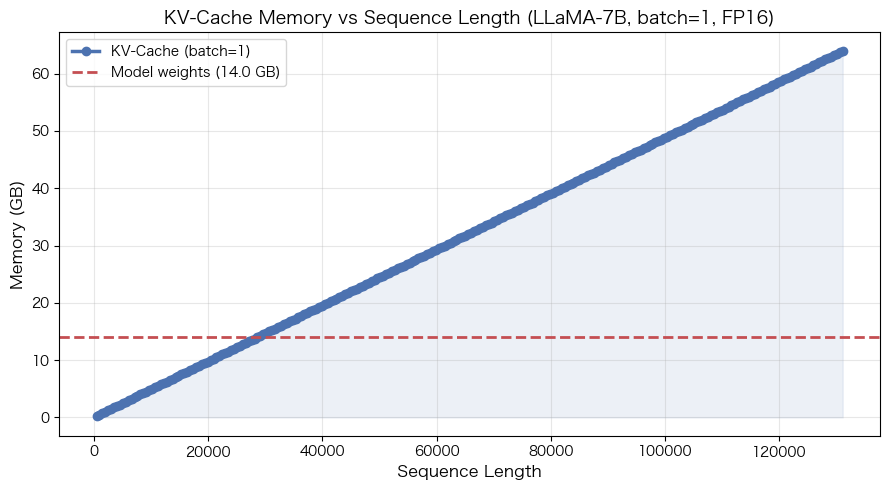

In [7]:
# Visualize: KV-cache growth for LLaMA-7B
fig, ax = draw_kv_cache_growth(
    seq_lengths=list(range(512, 131073, 512)),
    n_layers=32, n_kv_heads=32, head_dim=128,
    model_weight_gb=14.0,
    title="KV-Cache Memory vs Sequence Length (LLaMA-7B, batch=1, FP16)"
)
plt.show()

In [8]:
# Now with batching: the cache scales linearly with batch size too
batch_sizes = [1, 4, 16, 64, 256]
seq_len = 4096  # typical context
cfg = models["LLaMA-7B"]

print(f"KV-Cache memory at seq_len={seq_len} for LLaMA-7B (FP16):\n")
print(f"{'Batch Size':>10} | {'KV-Cache (GB)':>13} | {'vs Weights':>10} | {'vs 80GB GPU':>11}")
print("-" * 55)
for bs in batch_sizes:
    mem = kv_cache_memory_bytes(
        cfg["layers"], cfg["kv_heads"], cfg["head_dim"], seq_len, bs
    ) / (1024**3)
    print(f"{bs:>10} | {mem:>12.2f}  | {mem/cfg['params_gb']:>9.1%} | {mem/80:>10.1%}")

print("\n→ Batch size is often the main KV-cache bottleneck in serving!")

KV-Cache memory at seq_len=4096 for LLaMA-7B (FP16):

Batch Size | KV-Cache (GB) | vs Weights | vs 80GB GPU
-------------------------------------------------------
         1 |         2.00  |     14.3% |       2.5%
         4 |         8.00  |     57.1% |      10.0%
        16 |        32.00  |    228.6% |      40.0%
        64 |       128.00  |    914.3% |     160.0%
       256 |       512.00  |   3657.1% |     640.0%

→ Batch size is often the main KV-cache bottleneck in serving!


**核心要点：** 在推理服务中，KV-cache 的显存主要由以下因素决定：
- **Batch size** × **序列长度** —— 两者都使缓存线性增长
- 对于高吞吐量服务（大 batch），KV-cache 很快就会成为显存瓶颈

这就是为什么 PagedAttention（notebook 03）、MQA/GQA（见下文）以及量化 KV-cache 等技术对生产环境的推理服务至关重要。

---
## 4. MQA 和 GQA：通过共享 Head 来减小 KV-Cache

标准 Multi-Head Attention（MHA）的 Q、K、V head 数量相同。但 **K 和 V head 才是缓存的瓶颈**，而非 Q head（Q 仅为新 token 计算）。

以下两项关键创新减小了 KV-cache 的大小：

| 方法 | Q Heads | KV Heads | 缓存压缩比 | 使用模型 |
|--------|---------|----------|----------------|----------|
| **MHA** | $H$ | $H$ | 1×（基准） | GPT-3, LLaMA-1 |
| **GQA**（Grouped-Query） | $H$ | $H/G$ | $G$× | LLaMA-2/3 70B |
| **MQA**（Multi-Query） | $H$ | 1 | $H$× | PaLM, Falcon |

在 GQA 中，多个 query head **共享**同一个 KV head。MQA 是极端情况，即**所有** query head 共享一个 KV head。

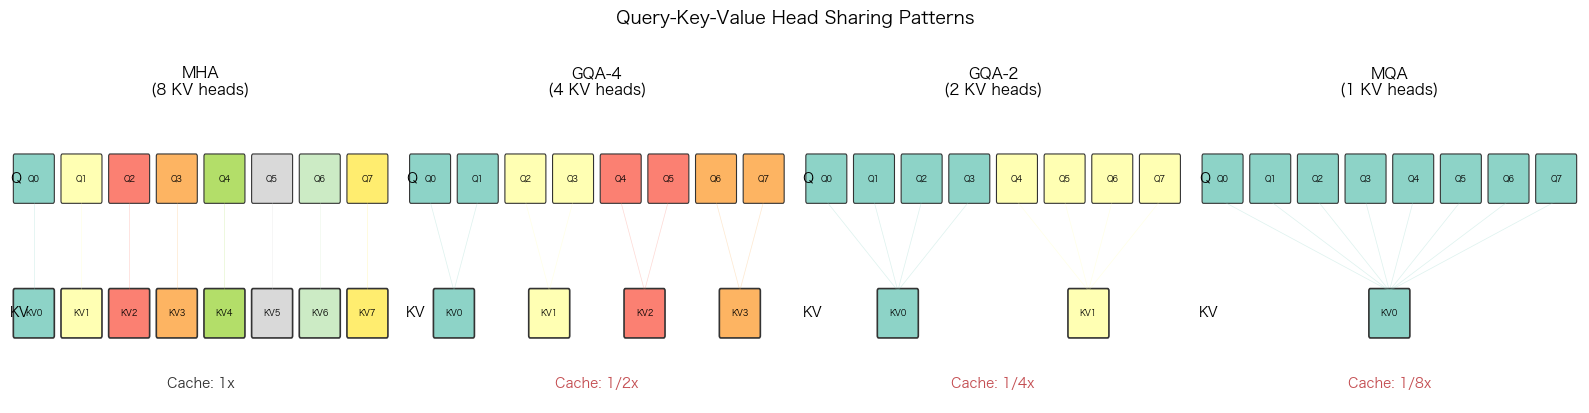

In [9]:
# Visualize MHA vs MQA vs GQA head sharing patterns
fig, axes = draw_mha_vs_mqa_vs_gqa(
    n_q_heads=8,
    n_kv_heads_list=[("MHA", 8), ("GQA-4", 4), ("GQA-2", 2), ("MQA", 1)],
    head_dim=128
)
plt.show()

In [10]:
# Demonstrate GQA with real tensors: fewer KV heads, same output quality
torch.manual_seed(42)
d_model = 64
n_q_heads = 8

configs = [
    ("MHA (8 KV heads)", 8),
    ("GQA (4 KV heads)", 4),
    ("GQA (2 KV heads)", 2),
    ("MQA (1 KV head)",  1),
]

x = torch.randn(1, 16, d_model)  # batch=1, seq_len=16

print(f"Input shape: {tuple(x.shape)}")
print(f"Q heads: {n_q_heads}, head_dim: {d_model // n_q_heads}\n")
print(f"{'Config':<20} | {'KV heads':>8} | {'KV params':>9} | {'Cache / token':>13}")
print("-" * 60)

for label, n_kv in configs:
    gqa = GroupedQueryAttention(d_model, n_q_heads, n_kv)
    out, (k, v) = gqa(x)
    
    kv_params = sum(p.numel() for p in [gqa.W_k.weight, gqa.W_v.weight])
    cache_per_token = 2 * n_kv * (d_model // n_q_heads)  # K + V, per token
    
    print(f"{label:<20} | {n_kv:>8} | {kv_params:>9,} | {cache_per_token:>13}")

print(f"\n→ MQA reduces cache by {n_q_heads}× vs MHA, GQA offers a middle ground.")

Input shape: (1, 16, 64)
Q heads: 8, head_dim: 8

Config               | KV heads | KV params | Cache / token
------------------------------------------------------------
MHA (8 KV heads)     |        8 |     8,192 |           128
GQA (4 KV heads)     |        4 |     4,096 |            64
GQA (2 KV heads)     |        2 |     2,048 |            32
MQA (1 KV head)      |        1 |     1,024 |            16

→ MQA reduces cache by 8× vs MHA, GQA offers a middle ground.


In [11]:
# Show how GQA broadcast works internally
torch.manual_seed(0)
d_model, n_q_heads, n_kv_heads = 32, 8, 2
head_dim = d_model // n_q_heads  # = 4
n_groups = n_q_heads // n_kv_heads  # = 4 Q heads per KV head

# Simulate: 2 KV heads, each shared by 4 Q heads
K_cache = torch.randn(1, n_kv_heads, 6, head_dim)  # 2 KV heads, 6 cached tokens

print(f"KV-cache shape: {tuple(K_cache.shape)}  (batch, {n_kv_heads} kv_heads, seq, head_dim)")
print(f"Q heads: {n_q_heads}, each group of {n_groups} Q heads shares 1 KV head\n")

# Expand KV heads to match Q heads via repeat_interleave
K_expanded = K_cache.repeat_interleave(n_groups, dim=1)
print(f"After broadcast: K shape = {tuple(K_expanded.shape)}  (now matches {n_q_heads} Q heads)")
print(f"Q heads 0-3 use KV head 0, Q heads 4-7 use KV head 1")

# Verify: heads within same group see identical K values
print(f"\nK[head 0] == K[head 3] (same group)? {torch.equal(K_expanded[0, 0], K_expanded[0, 3])}")
print(f"K[head 0] == K[head 4] (diff group)?  {torch.equal(K_expanded[0, 0], K_expanded[0, 4])}")

KV-cache shape: (1, 2, 6, 4)  (batch, 2 kv_heads, seq, head_dim)
Q heads: 8, each group of 4 Q heads shares 1 KV head

After broadcast: K shape = (1, 8, 6, 4)  (now matches 8 Q heads)
Q heads 0-3 use KV head 0, Q heads 4-7 use KV head 1

K[head 0] == K[head 3] (same group)? True
K[head 0] == K[head 4] (diff group)?  False


In [12]:
# Memory savings comparison for a real model
print("KV-Cache Memory Comparison at seq_len=4096, batch=32 (FP16):\n")

configs = [
    ("LLaMA-7B (MHA)",   32, 32, 128),
    ("LLaMA-70B (GQA-8)", 80,  8, 128),
    ("Falcon-40B (MQA)", 60,  1, 128),
]

seq_len = 4096
batch = 32

print(f"{'Model':<22} | {'KV Heads':>8} | {'Cache (GB)':>10} | {'per request':>11}")
print("-" * 60)
for name, layers, kv_heads, hdim in configs:
    total = kv_cache_memory_bytes(layers, kv_heads, hdim, seq_len, batch) / (1024**3)
    per_req = kv_cache_memory_bytes(layers, kv_heads, hdim, seq_len, 1) / (1024**3)
    print(f"{name:<22} | {kv_heads:>8} | {total:>9.2f}  | {per_req:>10.3f} GB")

KV-Cache Memory Comparison at seq_len=4096, batch=32 (FP16):

Model                  | KV Heads | Cache (GB) | per request
------------------------------------------------------------
LLaMA-7B (MHA)         |       32 |     64.00  |      2.000 GB
LLaMA-70B (GQA-8)      |        8 |     40.00  |      1.250 GB
Falcon-40B (MQA)       |        1 |      3.75  |      0.117 GB


---
## 5. Prefill 与 Decode 阶段

在实际应用中，LLM 推理包含**两个不同的阶段**：

| 阶段 | 执行内容 | 计算特征 | KV-Cache |
|-------|-------------|----------------|----------|
| **Prefill** | 并行处理整个输入 prompt | **计算密集型**（高算术强度） | 为所有 prompt token 填充缓存 |
| **Decode** | 逐个生成输出 token | **访存密集型**（低算术强度） | 每步追加一对 K/V |

在 **prefill** 阶段，我们一次性处理 $P$ 个 prompt token —— attention 矩阵为 $P \times P$，每次内存访问对应大量计算。这是高效的 GPU 利用方式。

在 **decode** 阶段，我们每次只处理**1 个 token** —— 需要从显存中加载全部模型权重，却只做 $1 \times S$ 的 attention 运算。GPU 大部分时间都在等待内存读取。这就是 decode 成为瓶颈的原因。

In [13]:
# Arithmetic intensity comparison: prefill vs decode
d_model = 4096  # typical hidden dim
n_layers = 32
prompt_len = 512
model_bytes = 7e9 * 2  # 7B params in FP16

# Prefill: process all prompt tokens at once
prefill_flops = 2 * model_bytes / 2 * prompt_len  # ~2 FLOPs per param per token
prefill_bytes = model_bytes  # read model weights once
prefill_intensity = prefill_flops / prefill_bytes

# Decode: process 1 token
decode_flops = 2 * model_bytes / 2 * 1  # same model, 1 token
decode_bytes = model_bytes  # still read all model weights
decode_intensity = decode_flops / decode_bytes

print("Arithmetic Intensity (FLOPs / byte loaded):")
print(f"  Prefill ({prompt_len} tokens): {prefill_intensity:.0f} FLOPs/byte")
print(f"  Decode  (1 token):        {decode_intensity:.0f} FLOPs/byte")
print(f"\n  Ratio: prefill is {prefill_intensity/decode_intensity:.0f}× more compute-dense")
print(f"\nA100 GPU:  312 TFLOPS / 2 TB/s = 156 FLOPs/byte (roofline)")
print(f"  → Prefill: compute-bound (intensity {prefill_intensity:.0f} > 156)")
print(f"  → Decode:  memory-bound  (intensity {decode_intensity:.0f} < 156)")

Arithmetic Intensity (FLOPs / byte loaded):
  Prefill (512 tokens): 512 FLOPs/byte
  Decode  (1 token):        1 FLOPs/byte

  Ratio: prefill is 512× more compute-dense

A100 GPU:  312 TFLOPS / 2 TB/s = 156 FLOPs/byte (roofline)
  → Prefill: compute-bound (intensity 512 > 156)
  → Decode:  memory-bound  (intensity 1 < 156)


---
## 总结

| 概念 | 核心思想 | 影响 |
|---------|----------|--------|
| **KV-Cache** | 存储已计算的 K、V 张量，避免重复计算 | 将 decode 总 FLOPs 从 $O(S^3)$ 降至 $O(S^2)$ |
| **缓存显存** | $2 \times L \times H_{kv} \times d \times S \times B$ | 随 seq_len × batch_size 线性增长 |
| **GQA/MQA** | 在 query 组间共享 KV head | 缓存缩减 $G$×（GQA）或 $H$×（MQA） |
| **Prefill/Decode** | 两个具有不同瓶颈的阶段 | Prefill = 计算密集型，Decode = 访存密集型 |

KV-cache 是所有 LLM 推理服务优化的**基石**：
- **PagedAttention**（notebook 03）通过分块分页管理 KV-cache 显存
- **Prefix Caching**（notebook 04）在共享前缀的请求之间复用 KV-cache
- **Speculative Decoding**（notebook 06）通过一次验证多个 token 来摊销 decode 瓶颈

### 延伸阅读
- [Multi-Query Attention (Shazeer, 2019)](https://arxiv.org/abs/1911.02150)
- [GQA: Training Generalized Multi-Query Transformer Models (Ainslie et al., 2023)](https://arxiv.org/abs/2305.13245)
- 下一篇 notebook：**[01-flash-attention](01-flash-attention.ipynb)** —— 让 attention 本身更省内存